<a href="https://colab.research.google.com/github/RamonEppens/Analisis_Predictivo_Co2/blob/main/notebooks/Examen1-An%C3%A1lisisPredictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo — Examen 1
## Predicción de emisiones de CO₂ per cápita por país
**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions  
**Fuente:** github.com/owid/co2-data  
**Grupo:** Ramón Eppens · Moira Patricia Clacin · María Belen Piuma Justo

**ITBA — 2026**

In [1]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual general
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("Librerías cargadas correctamente. ")

Librerías cargadas correctamente ✓


In [2]:
# === CARGA DEL DATASET ===
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado correctamente.
Dimensiones: 50,411 filas × 79 columnas


In [3]:
# === PRIMER VISTAZO ===
df.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Tipos de datos por columna
df.dtypes.value_counts()

,count
float64,76
object,2
int64,1


In [5]:
# Ver todas las columnas disponibles
for i, col in enumerate(df.columns):
    print(f"{i+1:>3}. {col}")

  1. country
  2. year
  3. iso_code
  4. population
  5. gdp
  6. cement_co2
  7. cement_co2_per_capita
  8. co2
  9. co2_growth_abs
 10. co2_growth_prct
 11. co2_including_luc
 12. co2_including_luc_growth_abs
 13. co2_including_luc_growth_prct
 14. co2_including_luc_per_capita
 15. co2_including_luc_per_gdp
 16. co2_including_luc_per_unit_energy
 17. co2_per_capita
 18. co2_per_gdp
 19. co2_per_unit_energy
 20. coal_co2
 21. coal_co2_per_capita
 22. consumption_co2
 23. consumption_co2_per_capita
 24. consumption_co2_per_gdp
 25. cumulative_cement_co2
 26. cumulative_co2
 27. cumulative_co2_including_luc
 28. cumulative_coal_co2
 29. cumulative_flaring_co2
 30. cumulative_gas_co2
 31. cumulative_luc_co2
 32. cumulative_oil_co2
 33. cumulative_other_co2
 34. energy_per_capita
 35. energy_per_gdp
 36. flaring_co2
 37. flaring_co2_per_capita
 38. gas_co2
 39. gas_co2_per_capita
 40. ghg_excluding_lucf_per_capita
 41. ghg_per_capita
 42. land_use_change_co2
 43. land_use_change_co2_per_

## 1. Descripción general del dataset

In [6]:
# === DIMENSIONES Y TIPOS DE DATOS ===
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

Filas:    50,411
Columnas: 79

Tipos de datos:
float64    76
object      2
int64       1
Name: count, dtype: int64


In [7]:
# === INFO GENERAL ===
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

### 1.1 Estadísticas descriptivas

In [8]:
# === ESTADÍSTICAS DESCRIPTIVAS ===
# Solo columnas numéricas, redondeado a 2 decimales
df.describe().round(2)

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.00,4.116700e+04,1.525100e+04,29173.00,25648.00,29384.00,27216.00,26239.00,23796.00,23496.00,...,2170.00,41238.00,38280.00,41238.00,41238.00,38280.00,38150.00,37813.00,4712.00,4712.00
mean,1920.35,6.017453e+07,3.300495e+11,7.89,0.06,420.23,6.27,42.60,544.14,7.48,...,7.19,2.27,0.00,0.01,0.01,0.00,490.80,310.52,-6.99,21.47
std,65.86,3.308433e+08,3.086383e+12,62.99,0.12,1972.09,62.20,1721.91,2273.28,99.51,...,17.45,9.28,0.02,0.05,0.06,0.00,2414.08,1812.36,259.02,62.64
min,1750.00,2.150000e+02,4.998000e+07,0.00,0.00,0.00,-1928.34,-100.00,-84.56,-2298.98,...,0.00,-0.82,-0.00,0.00,-0.00,0.00,-19.73,0.00,-2177.81,-98.28
25%,1875.00,3.272140e+05,7.874038e+09,0.00,0.00,0.38,-0.00,-1.07,6.67,-0.73,...,0.14,0.00,0.00,0.00,0.00,0.00,1.50,0.22,-2.26,-6.83
50%,1925.00,2.291594e+06,2.743861e+10,0.00,0.00,5.08,0.04,3.81,28.12,0.11,...,0.59,0.08,0.00,0.00,0.00,0.00,14.61,2.22,1.64,8.38
75%,1975.00,9.986553e+06,1.212627e+11,0.52,0.08,53.66,1.02,10.88,124.30,2.77,...,2.42,0.37,0.00,0.00,0.00,0.00,76.51,27.86,11.43,32.78
max,2024.00,8.161973e+09,1.301126e+14,1666.88,2.48,38598.58,1804.66,180870.00,43184.09,2614.87,...,100.00,100.00,0.38,1.22,1.68,0.08,54433.40,43714.78,1768.85,1023.04


### 1.2 Valores faltantes

Columnas con valores faltantes: 77 de 79
Columnas sin ningún nulo:       2



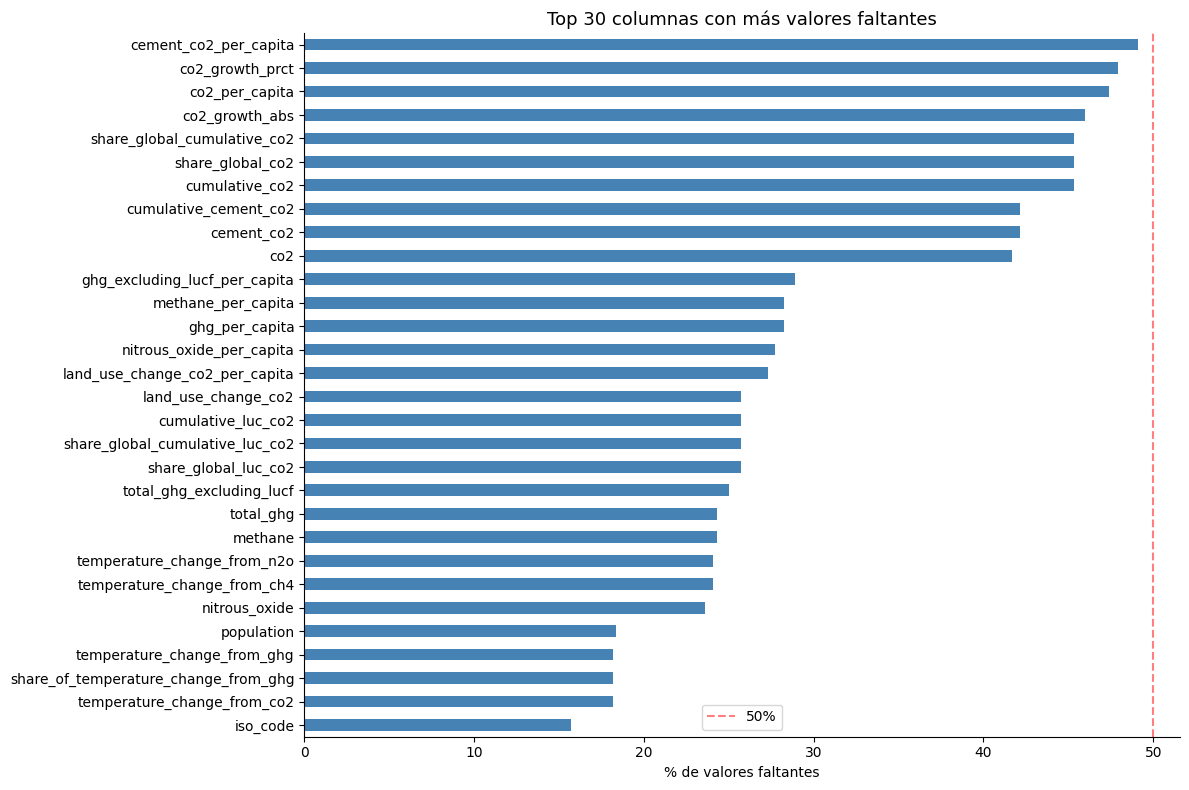

In [10]:
# === VALORES FALTANTES ===
# Calcular % de nulos por columna
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]  # Solo columnas con al menos un nulo

print(f"Columnas con valores faltantes: {len(missing)} de {df.shape[1]}")
print(f"Columnas sin ningún nulo:       {df.shape[1] - len(missing)}\n")

# Graficar las 30 columnas con más nulos
fig, ax = plt.subplots(figsize=(12, 8))
missing.sort_values(ascending=True).head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 30 columnas con más valores faltantes', fontsize=13)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Cobertura temporal y geográfica

In [11]:
# === COBERTURA TEMPORAL Y GEOGRÁFICA ===
print(f"Rango de años: {df['year'].min()} — {df['year'].max()}")
print(f"Países/regiones únicos: {df['country'].nunique()}")
print(f"\nPrimeros y últimos años con datos:")
print(df.groupby('year')['country'].count().head(5).to_string())
print("...")
print(df.groupby('year')['country'].count().tail(5).to_string())

Rango de años: 1750 — 2024
Países/regiones únicos: 254

Primeros y últimos años con datos:
year
1750    58
1751    58
1752    58
1753    58
1754    58
...
year
2020    254
2021    254
2022    254
2023    254
2024    254


In [12]:
# === IDENTIFICAR AGREGADOS REGIONALES ===
# OWID incluye no solo países sino también regiones agregadas
# (ej: "World", "Asia", "Europe") — hay que identificarlos para filtrarlos después

# Los agregados no tienen código ISO de 3 letras
aggregates = df[df['iso_code'].isna()]['country'].unique()
print(f"Agregados regionales encontrados ({len(aggregates)}):")
for a in sorted(aggregates):
    print(f"  - {a}")

Agregados regionales encontrados (36):
  - Africa
  - Africa (GCP)
  - Asia
  - Asia (GCP)
  - Asia (excl. China and India)
  - Central America (GCP)
  - Europe
  - Europe (GCP)
  - Europe (excl. EU-27)
  - Europe (excl. EU-28)
  - European Union (27)
  - European Union (28)
  - High-income countries
  - International aviation
  - International shipping
  - Kosovo
  - Kuwaiti Oil Fires
  - Kuwaiti Oil Fires (GCP)
  - Least developed countries (Jones et al.)
  - Low-income countries
  - Lower-middle-income countries
  - Middle East (GCP)
  - Non-OECD (GCP)
  - North America
  - North America (GCP)
  - North America (excl. USA)
  - OECD (GCP)
  - OECD (Jones et al.)
  - Oceania
  - Oceania (GCP)
  - Ryukyu Islands
  - Ryukyu Islands (GCP)
  - South America
  - South America (GCP)
  - Upper-middle-income countries
  - World


## 2. Filtros y limpieza

### 2.1 Eliminar agregados regionales

In [13]:
# === ELIMINAR AGREGADOS REGIONALES ===
# Nos quedamos solo con países reales (los que tienen código ISO)
df_countries = df[df['iso_code'].notna()].copy()

print(f"Dataset original:  {df.shape[0]:,} filas · {df['country'].nunique()} entidades")
print(f"Solo países:       {df_countries.shape[0]:,} filas · {df_countries['country'].nunique()} países")
print(f"Filas eliminadas:  {df.shape[0] - df_countries.shape[0]:,}")

Dataset original:  50,411 filas · 254 entidades
Solo países:       42,480 filas · 218 países
Filas eliminadas:  7,931


### 2.2 Filtro temporal: 1990–2024

In [14]:
# === FILTRO TEMPORAL ===
# Pre-1990: muy pocos países reportan datos completos
# Post-2022: datos incompletos (lag de publicación)
df_clean = df_countries[
    (df_countries['year'] >= 1990) &
    (df_countries['year'] <= 2024)
].copy()

print(f"Con filtro temporal: {df_clean.shape[0]:,} filas")
print(f"Años cubiertos:      {df_clean['year'].min()} — {df_clean['year'].max()}")
print(f"Países:              {df_clean['country'].nunique()}")

Con filtro temporal: 7,630 filas
Años cubiertos:      1990 — 2024
Países:              218


### 2.3 Selección de variables relevantes